# 03 — Event Detection

The core signal processing step: detecting when appliances switch ON or OFF.

**The problem:**
The smart meter only measures total household power consumption. To identify individual appliances, we first need to detect moments where the aggregate signal changes significantly. These changes correspond to appliance ON/OFF events.

**Approach: Edge detection on the power signal**
1. Smooth the signal to remove noise (median filter)
2. Compute first-order difference (rate of change)
3. Flag points where |Δpower| exceeds a threshold
4. Suppress duplicate detections within a time window

The key idea is that appliance switching creates sharp changes in power. By detecting these transitions, we can convert a continuous power signal into a sequence of appliance events.

### Hypothesis

Before implementing the detector, I expected that large appliances such as the washer dryer and microwave would create obvious power transitions, while smaller appliances might be harder to detect because their changes could be hidden within background household consumption.

In [10]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import medfilt
import warnings
warnings.filterwarnings('ignore')

from utils.signal_utils import detect_events

plt.style.use('seaborn-v0_8-whitegrid')

In [11]:
df = pd.read_csv('../data/processed/house1_7days.csv', index_col=0, parse_dates=True)
mains = df['mains']
print(f'Loaded: {len(mains)} samples, {len(mains)/3600:.1f} hours')

Loaded: 604800 samples, 168.0 hours


## Step 1: Effect of smoothing

Raw aggregate power contains small fluctuations caused by measurement noise and normal appliance variability. Before detecting events, it is useful to smooth the signal while preserving the sharp transitions associated with appliance switching.
A median filter removes these without blurring the edges we care about.

Comparing raw vs smoothed:

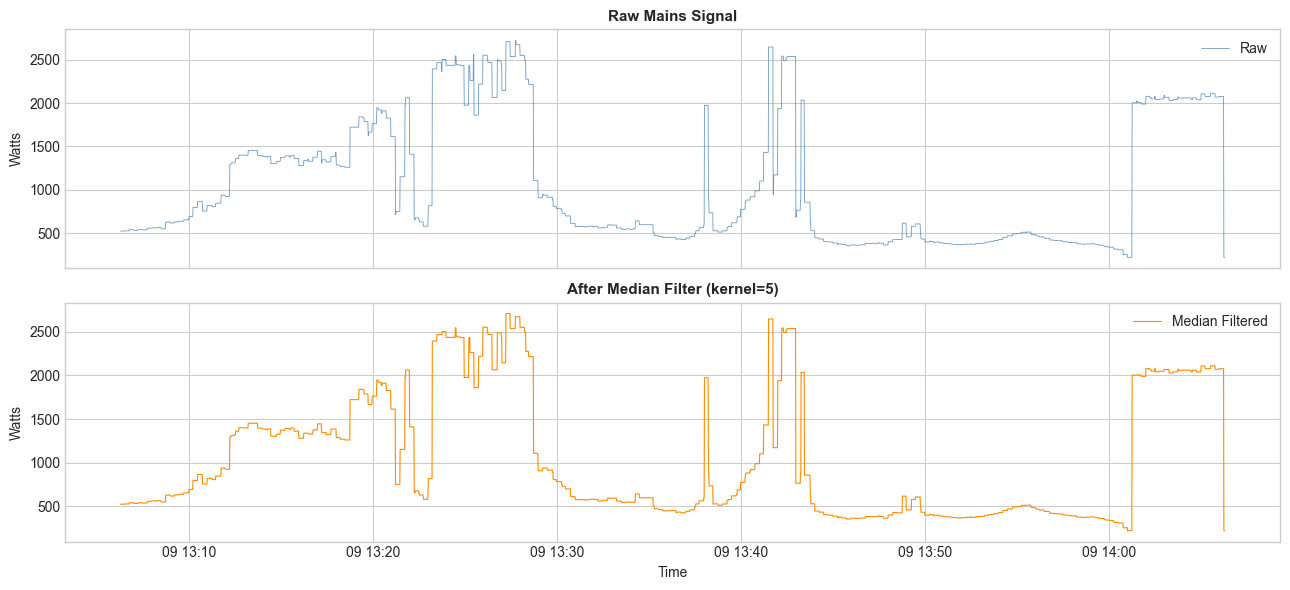

In [12]:
# take 1 hour slice for visualization
slice_1h = mains.iloc[:3600]
smoothed = pd.Series(medfilt(slice_1h.values, kernel_size=5), index=slice_1h.index)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(slice_1h.index, slice_1h.values, color='steelblue', linewidth=0.6, alpha=0.8, label='Raw')
axes[0].set_title('Raw Mains Signal', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Watts')
axes[0].legend()

axes[1].plot(smoothed.index, smoothed.values, color='darkorange', linewidth=0.8, label='Median Filtered')
axes[1].set_title('After Median Filter (kernel=5)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Watts')
axes[1].set_xlabel('Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_smoothing_comparison.png', dpi=150)
plt.show()

## My Observations

The median filter successfully reduced small fluctuations while preserving the major power transitions in the aggregate signal. Most appliance switching events remain clearly visible after filtering.

This suggests that median filtering is a suitable preprocessing step because it removes noise without significantly altering the edges that will later be detected as appliance events.

## Step 2: Difference signal

Taking the first-order difference shows us the rate of change.
Spikes in the difference signal = step changes in power = appliance events.

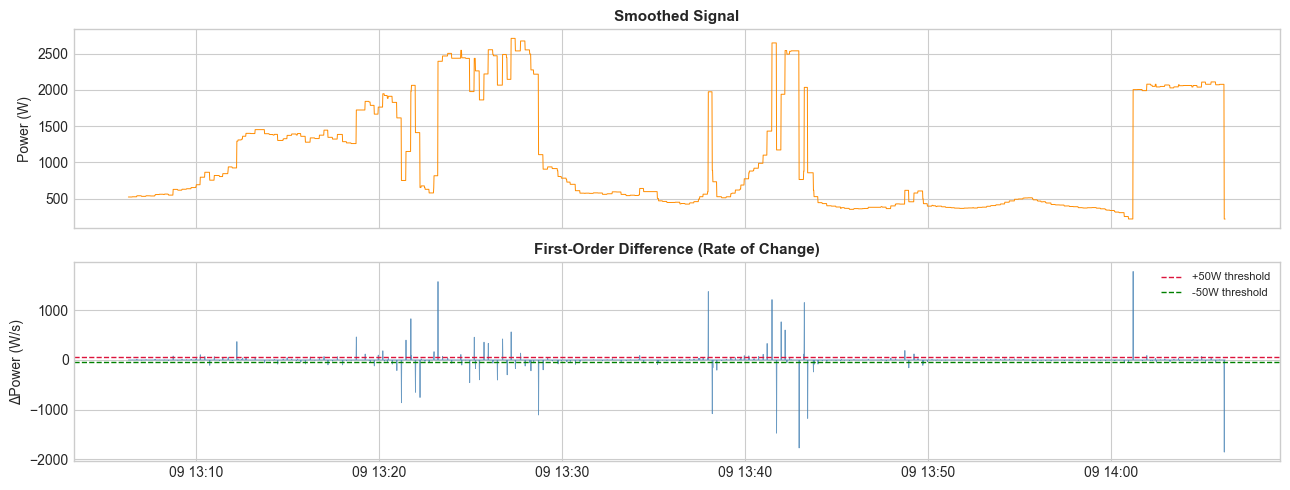

In [13]:
diff = smoothed.diff().fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(smoothed.index, smoothed.values, color='darkorange', linewidth=0.7)
axes[0].set_ylabel('Power (W)')
axes[0].set_title('Smoothed Signal', fontsize=11, fontweight='bold')

axes[1].plot(diff.index, diff.values, color='steelblue', linewidth=0.6, alpha=0.8)
axes[1].axhline(50, color='crimson', linestyle='--', linewidth=1, label='+50W threshold')
axes[1].axhline(-50, color='green', linestyle='--', linewidth=1, label='-50W threshold')
axes[1].set_ylabel('ΔPower (W/s)')
axes[1].set_title('First-Order Difference (Rate of Change)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/03_difference_signal.png', dpi=150)
plt.show()

## My Observations

The first-order difference converts appliance switching events into distinct positive and negative spikes. Positive spikes correspond to increases in aggregate power, while negative spikes correspond to decreases.

Most normal fluctuations remain close to zero, whereas appliance transitions produce much larger changes that exceed the ±50 W threshold. This makes the difference signal a convenient representation for detecting ON/OFF events in the aggregate power trace.

## Step 3: Selecting the event detection threshold

The event detector relies on a power-change threshold to distinguish genuine appliance transitions from small fluctuations.

To select an appropriate value, I evaluated several thresholds and measured the number of detected events. A very low threshold produces excessive detections, while a very high threshold misses smaller appliance activities.

The goal is to choose a value that balances sensitivity and robustness.

Threshold   20W -> 3104 events
Threshold   30W -> 2383 events
Threshold   50W -> 1681 events
Threshold   75W -> 1245 events
Threshold  100W -> 1041 events
Threshold  150W ->  855 events
Threshold  200W ->  750 events


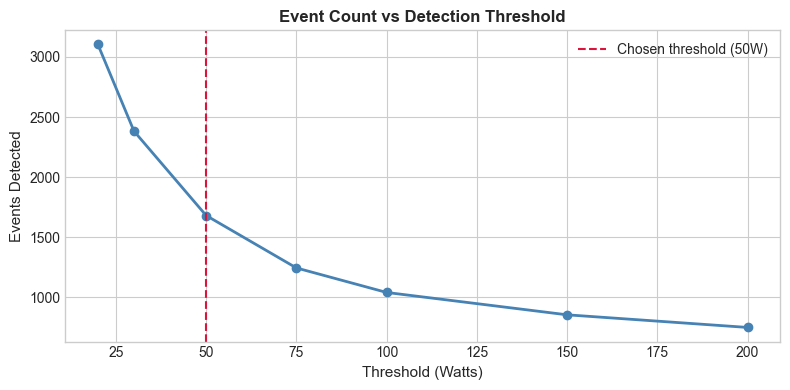

In [14]:
thresholds = [20, 30, 50, 75, 100, 150, 200]
counts = []
for t in thresholds:
    ev = detect_events(mains, threshold=t)
    counts.append(len(ev))
    print(f'Threshold {t:4d}W -> {len(ev):4d} events')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, counts, marker='o', color='steelblue', linewidth=2)
ax.axvline(50, color='crimson', linestyle='--', linewidth=1.5, label='Chosen threshold (50W)')
ax.set_xlabel('Threshold (Watts)', fontsize=11)
ax.set_ylabel('Events Detected', fontsize=11)
ax.set_title('Event Count vs Detection Threshold', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_threshold_sensitivity.png', dpi=150)
plt.show()

## My Observations

The number of detected events decreases rapidly as the threshold increases. At 20 W, more than 3000 events are detected, suggesting that many small fluctuations are being classified as appliance transitions.

Above 100 W, the event count begins to stabilize, but smaller appliance activations may be missed. A threshold of 50 W provides a reasonable compromise, retaining a substantial number of events while avoiding excessive sensitivity to noise.

Based on this analysis, 50 W was selected for subsequent event detection experiments.

## Step 4: Run event detection

After selecting a 50 W threshold, the event detector is applied to the full 7-day aggregate power signal. Each detected event represents a significant increase or decrease in power that may correspond to an appliance switching ON or OFF.


In [15]:
# detect events on full 7-day mains signal
events = detect_events(mains, threshold=50, min_gap_seconds=3)

print(f'Events detected: {len(events)}')
print(f'ON events: {(events["direction"]=="ON").sum()}')
print(f'OFF events: {(events["direction"]=="OFF").sum()}')
events.head(10)

Events detected: 1681
ON events: 808
OFF events: 873


,timestamp,delta_power,direction
0,2013-10-09 13:08:44,79.0,ON
1,2013-10-09 13:10:13,104.0,ON
2,2013-10-09 13:10:28,68.0,ON
3,2013-10-09 13:10:44,-109.0,OFF
4,2013-10-09 13:10:59,65.0,ON
5,2013-10-09 13:11:45,57.0,ON
6,2013-10-09 13:12:13,369.0,ON
7,2013-10-09 13:13:13,54.0,ON
8,2013-10-09 13:13:44,-56.0,OFF
9,2013-10-09 13:14:27,-84.0,OFF


## Step 5: Validate detected events on the aggregate signal

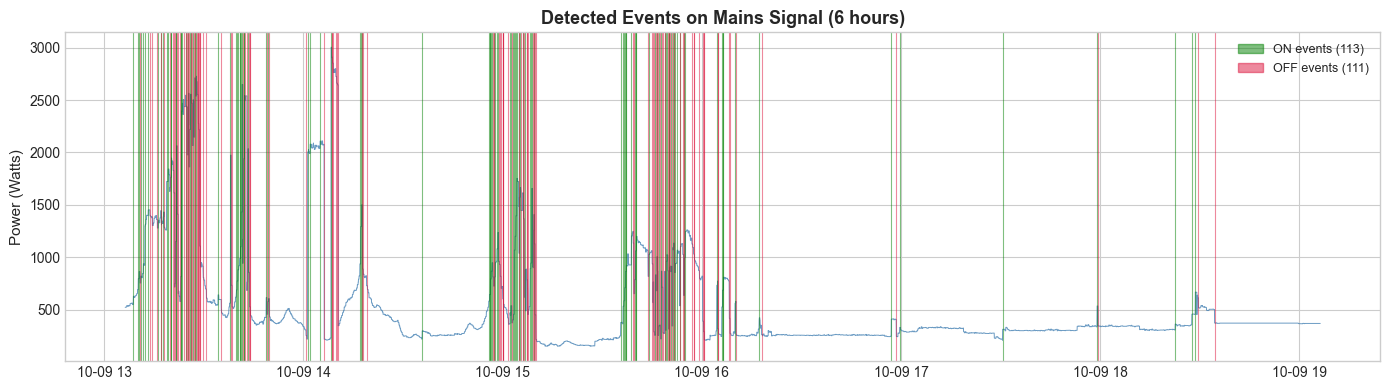

In [16]:
# plot 6 hours with events marked
slice_6h = mains.iloc[:6*3600]
events_6h = events[events['timestamp'] <= slice_6h.index[-1]]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(slice_6h.index, slice_6h.values, color='steelblue', linewidth=0.7, alpha=0.8, zorder=1)

# mark ON events green, OFF events red
on_events  = events_6h[events_6h['direction'] == 'ON']
off_events = events_6h[events_6h['direction'] == 'OFF']

for ts in on_events['timestamp']:
    ax.axvline(ts, color='green', alpha=0.5, linewidth=0.8)
for ts in off_events['timestamp']:
    ax.axvline(ts, color='crimson', alpha=0.5, linewidth=0.8)

patch_on  = mpatches.Patch(color='green', alpha=0.5, label=f'ON events ({len(on_events)})')
patch_off = mpatches.Patch(color='crimson', alpha=0.5, label=f'OFF events ({len(off_events)})')
ax.legend(handles=[patch_on, patch_off], fontsize=9)
ax.set_ylabel('Power (Watts)', fontsize=11)
ax.set_title('Detected Events on Mains Signal (6 hours)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_detected_events.png', dpi=150)
plt.show()

## My Observations

Most detected events coincide with visible step changes in the aggregate power trace, indicating that the edge-detection approach successfully captures appliance switching activity.

Clusters of closely spaced detections are also visible. These likely correspond to multi-state appliances, compressor cycling, or short transient behaviors rather than completely independent appliance activations.

Overall, the results suggest that the chosen threshold provides a reasonable balance between sensitivity and noise rejection.

In [8]:
# save events for next notebook
events.to_csv('../data/processed/detected_events.csv', index=False)
print(f'Saved {len(events)} events.')

Saved 1681 events.


## Conclusion

This notebook developed and validated an event-detection pipeline for NILM using low-frequency aggregate power data.

A median filter was first applied to reduce measurement noise while preserving appliance switching transitions. The first-order difference signal transformed these transitions into easily identifiable spikes, enabling edge-based event detection.

By evaluating multiple detection thresholds, a value of 50 W was selected as a practical compromise between sensitivity and robustness. Applying the detector to the full dataset identified 1,681 appliance switching events over the observation period.

The detected events aligned well with visible power transitions in the aggregate signal, demonstrating that edge-based event detection is effective for extracting appliance activity from low-frequency smart-meter data.

The resulting event timestamps will be used in the next notebook to engineer appliance fingerprints and extract features for classification.